# Análisis de Datos III

In [1]:
import pandas as pd

In [2]:
# Importar base de datos de exoplanetas
data_url = "https://exoplanetarchive.ipac.caltech.edu/cgi-bin/nstedAPI/nph-nstedAPI?table=cumulative&select=kepid,kepoi_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr&format=csv"
df_0 = pd.read_csv(data_url)

In [4]:
# Eliminación de los renglones que contienen valores NaN
df_1=df_0.dropna().reset_index(drop=True)

In [5]:
def filtro(base,col,factor):
  '''Función que elimina datos de las colas de la columna indicada de una base de datos determinando el indice intercuartílico
y seleccionando elementos que están por encima del tercer cuartil a una distancia indice_intercuartil*factor y elementos que están por abajo del segundo cuartil a la misma distancia'''
  indice_intercuartil=base[col].quantile(0.75)-base[col].quantile(0.25)
  filtro_inferior=base[col]>base[col].quantile(0.25)-(indice_intercuartil*factor)
  filtro_superior=base[col]<base[col].quantile(0.75)+(indice_intercuartil*factor)
  return base[filtro_inferior & filtro_superior]

In [6]:
# Dataframe filtrado con respecto al radio planetario
df_2=filtro(df_1,'koi_prad',2)

**Teorema del límite central**

In [18]:
def dist_medias(base,col,N):
  ''' Función que toma 100000 muestras de tamaño N de los datos en base.col, con remplazo, calcula la media algebraica y la almacena en una lista.'''
  medias=[]
  for i in range(100_000):
    muestra=(base[col]).sample(n=N,replace=True)
    medias.append(muestra.mean())
  return pd.Series(medias)
  # Reto: optimizar este código para evitar el lazo usando NumPy arrays o directamente Series de Pandas

In [19]:
medias_radio=dist_medias(df_2,'koi_prad',int(df_2.koi_prad.size*0.2))

In [21]:
import seaborn as sns

[Text(0.5, 0, 'Radio (Radios Terrestres)'),
 Text(0, 0.5, 'Distribución de probabilidad')]

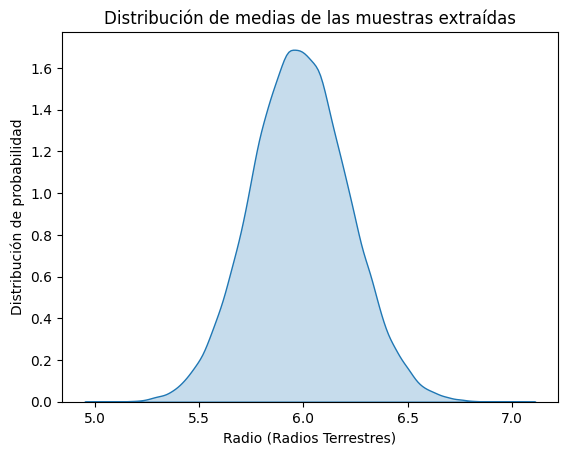

In [26]:
graf_1=sns.kdeplot(medias_radio,fill=True)
graf_1.set_title('Distribución de medias de las muestras extraídas')
graf_1.set(xlabel='Radio (Radios Terrestres)',ylabel='Distribución de probabilidad')

Estimado de Sesgo: Aimetría estadística

In [27]:
medias_radio.skew()

np.float64(0.05162310409898541)

Estimado de concentración de datos en el centro: Kurtosis relativa

In [28]:
medias_radio.kurtosis()

np.float64(0.029804525915693603)

Desviación Estándar

In [29]:
medias_radio.std()

0.2336290798414799

In [30]:
# Estimación del teorema del límite central
from numpy import sqrt
(df_2.koi_prad).std()/sqrt((df_2.koi_prad).size*0.2)

np.float64(0.2339723289621654)